In [1]:
import matplotlib.pyplot as plt

In [2]:
import pickle
# with open('data/ll_eval_153.pkl', 'rb') as f: #Eval over all axis
with open('data/ll_eval_dc111.pkl', 'rb') as f: #2D grid search over propensity, atrisk
    ll_eval = pickle.load(f)

In [3]:
import numpy as np
import pickle
from stat_utils import CityParams, EventOutcome, GeneralParams
from city_data import city_data_base, subsampled_city_data, subsample_weights

n_event = np.array([len(c['events']) for c in subsampled_city_data])

In [4]:
total_ll = {params: (subsample_weights.reshape((-1, 1))*city_eval).sum(axis=0)[0] for params, city_eval in ll_eval.items()}
param_groups = [p for p in ll_eval]
ll_list = [(subsample_weights.reshape((-1, 1))*ll_eval[p]).sum(axis=0) for p in param_groups]
import pandas as pd
result_df = pd.DataFrame(param_groups)
eval_df = pd.DataFrame(ll_list)
result_df = pd.concat([result_df, eval_df], axis=1)
result_df['city_eval'] = [ll_eval[p] for p in param_groups]


In [6]:
result_df[0].max()

-933.6817749835182

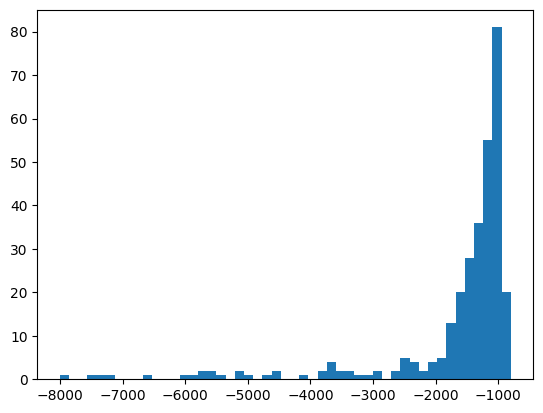

In [8]:
result_df[0]
plt.hist(result_df[0], bins=np.linspace(-8000, -800, 50))
plt.show()

In [9]:
df = result_df[['propensity', 'atrisk_gathering_rate', 0]]
df[result_df['propensity'] <= 1.0e-8].sort_values('atrisk_gathering_rate', ascending=False)


,propensity,atrisk_gathering_rate,0
83,9.135262e-09,5.000000e-04,-1117.538529
41,3.318387e-09,5.000000e-04,-1199.376753
62,5.505845e-09,5.000000e-04,-1151.620562
20,2.000000e-09,5.000000e-04,-1254.917976
61,5.505845e-09,3.075230e-04,-1108.687155
...,...,...,...
64,9.135262e-09,4.877684e-08,-inf
63,9.135262e-09,3.000000e-08,-inf
42,5.505845e-09,3.000000e-08,-inf
21,3.318387e-09,3.000000e-08,-inf


In [23]:
grid_height = {(p.propensity, p.atrisk_gathering_rate): ll for p, ll in total_ll.items()}
propensity_range = np.unique(result_df['propensity']); atrisk_range = np.unique(result_df['atrisk_gathering_rate'])
propensity_range.sort(); atrisk_range.sort()
Z = np.array([[grid_height.get((propensity_range[x], atrisk_range[y]), -np.inf) for x in range(len(propensity_range))] for y in range(len(atrisk_range))])


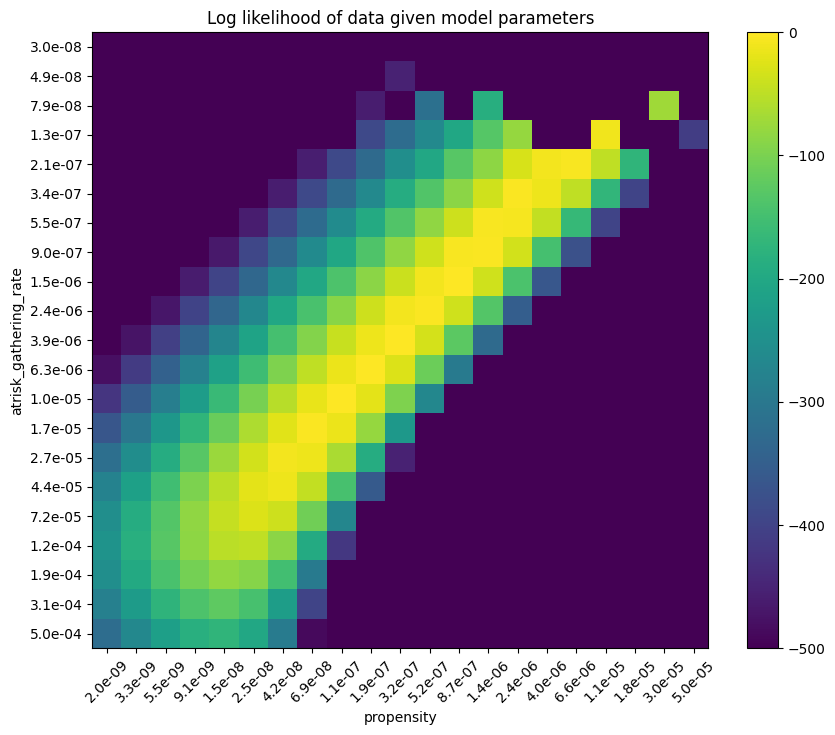

In [37]:
mat = Z - Z.max()
cutoff = -500
mat[np.isneginf(mat)] = cutoff
mat = mat*(mat > cutoff) + cutoff*(mat <= cutoff)

plt.imshow(mat)
plt.xticks(range(len(propensity_range)), ['%.1e' % p for p in propensity_range], rotation=45)
plt.yticks(range(len(atrisk_range)), ['%.1e' % p for p in atrisk_range])
plt.xlabel('propensity')
plt.ylabel('atrisk_gathering_rate')
plt.colorbar()
plt.title('Log likelihood of data given model parameters')
plt.show()

/tmp/ipykernel_2446573/1142763385.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


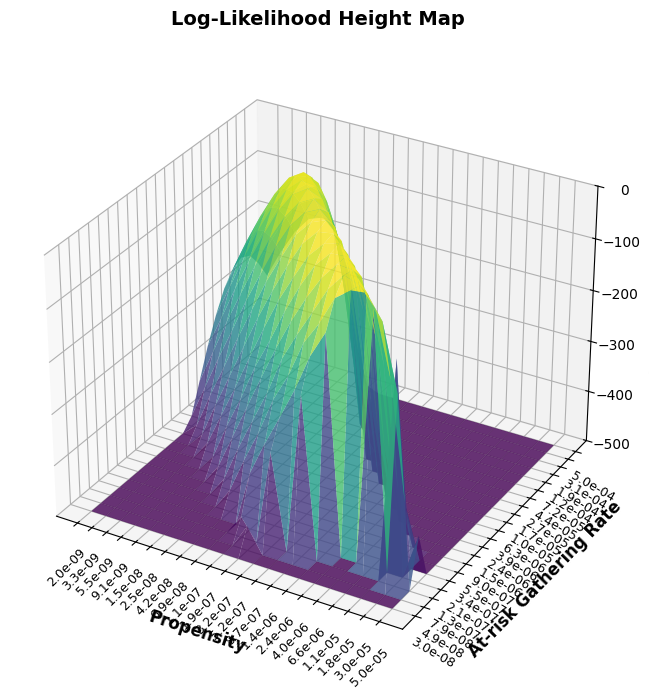

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib as mpl

# Assuming propensity_range, atrisk_range, and mat are already defined
# If not, you would define them here

# Set figure size and resolution
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100

# Create figure with a specific aspect ratio
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the meshgrid for plotting
X, Y = np.meshgrid(np.arange(len(propensity_range)), np.arange(len(atrisk_range)))

# Plot the surface with a professional colormap and lighting
surf = ax.plot_surface(
    X, Y, mat,
    cmap=cm.viridis,
    linewidth=0,
    antialiased=True,
    alpha=0.8,
    rstride=1,
    cstride=1,
)

# Customize the z-axis
ax.set_zlim(np.min(mat), np.max(mat))

# Add proper ticks for x and y axes using the actual range values
x_ticks = np.arange(len(propensity_range))
y_ticks = np.arange(len(atrisk_range))
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

# Set the actual values from propensity_range and atrisk_range as labels
# Comment out the next two lines if your ranges have too many values
ax.set_xticklabels([f"{p:.1e}" for p in propensity_range], fontsize=9, rotation=45)
ax.set_yticklabels([f"{a:.1e}" for a in atrisk_range], fontsize=9, rotation=-30)

# Add labels with better font styling
ax.set_xlabel('Propensity', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('At-risk Gathering Rate', fontsize=12, fontweight='bold', labelpad=10)
ax.set_zlabel('Log Likelihood', fontsize=12, fontweight='bold', labelpad=10)

# Add a title
ax.set_title('Log-Likelihood Height Map', fontsize=14, fontweight='bold', pad=20)

# Customize the grid
ax.grid(True, linestyle='--', alpha=0.6)

# Adjust the view angle for better visibility
# ax.view_init(elev=30, azim=45)

# Adjust the axes aspect ratio
# Set z-axis scale the same as x, y
# Uncomment if you want uniform scaling
# ax.set_box_aspect([1, 1, 0.7])

# Tight layout
plt.tight_layout()

# Save the figure with high resolution
# plt.savefig('log_likelihood_heightmap.png', dpi=300, bbox_inches='tight')

plt.show()

In [85]:
slice_param = 'propensity'
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)

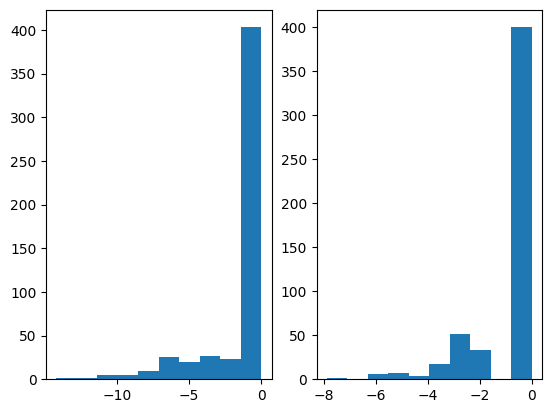

In [85]:
eval_slice_df = list(grouped)[30][1]
eval_slice_df
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2)
ind = 1
axes[0].hist(eval_slice_df.iloc[ind]['city_eval'][:, 1])
axes[1].hist(eval_slice_df.iloc[ind]['city_eval'][:, 2])
plt.show()


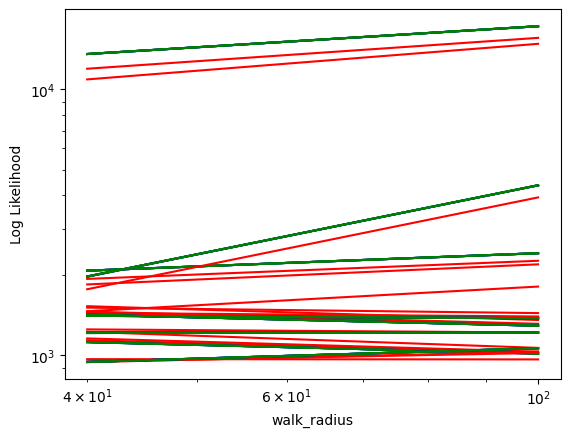

In [106]:
param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
slice_param = 'walk_radius'
param_cols.remove(slice_param)
grouped = result_df.groupby(param_cols)
#Plot the log likelihood for each parameter group against the propensity
#Convert arm bias to color with a colorbar
import matplotlib.pyplot as plt
colorbar = plt.cm.ScalarMappable(cmap='viridis')
colormap = {0.01: 'red', 1: 'blue', 100: 'green'}

fig, ax = plt.subplots()
for name, group in grouped:
    # print(group)
    # print(group['arm_bias'].iloc[0])
    # if group['arm_bias'].iloc[0] in [1, 100]:
    #     continue
    ax.plot(group[slice_param], -group[0], c=colormap[group['arm_bias'].iloc[0]])
ax.set_xlabel(slice_param)
ax.set_ylabel('Log Likelihood')
ax.set_xscale('log'); ax.set_yscale('log')
# ax.legend()

/tmp/ipykernel_1199115/1978540426.py:11: MatplotlibDeprecationWarning: Passing label as a length 4 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  ax.plot(group[slice_param], -group[0], label=name)


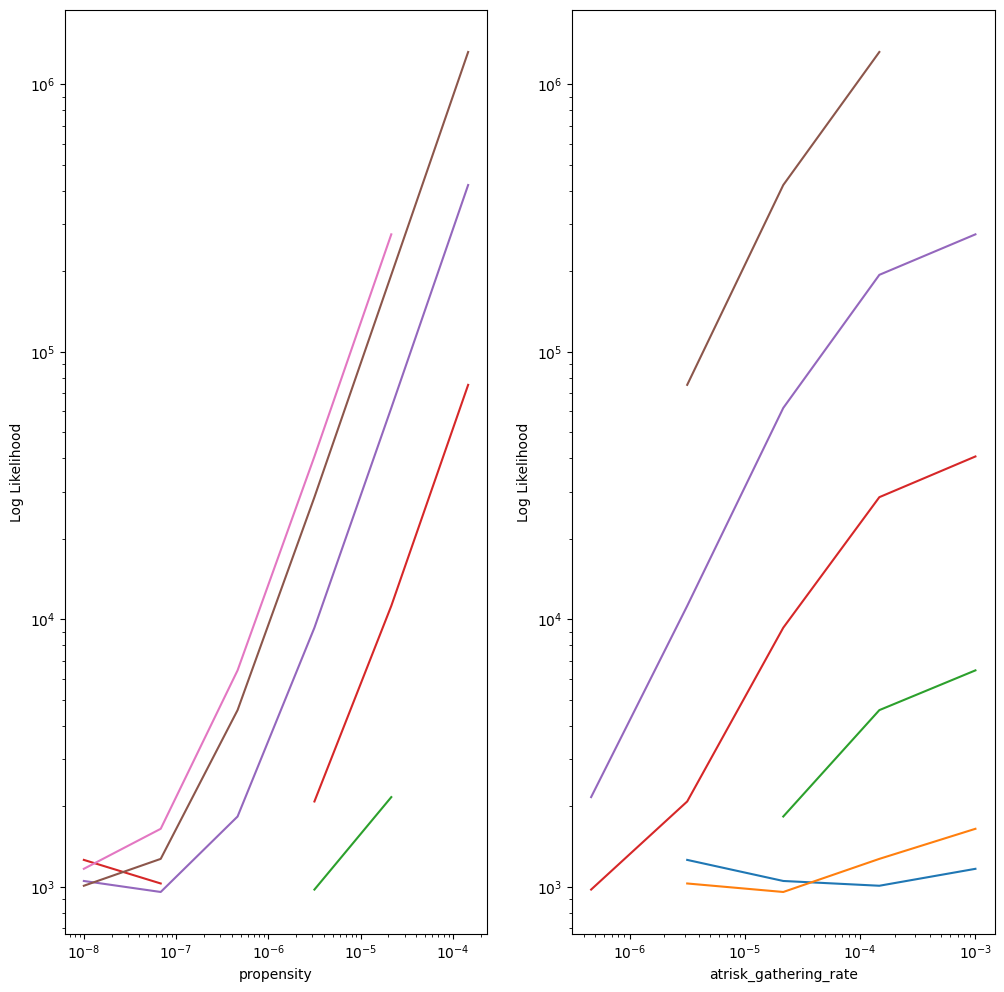

In [8]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 12))
for i, slice_param in enumerate(['propensity', 'atrisk_gathering_rate']):
    param_cols = ['propensity', 'walk_radius', 'arm_bias', 'arm_weight', 'atrisk_gathering_rate']
    param_cols.remove(slice_param)
    grouped = result_df.groupby(param_cols)
    #Plot the log likelihood for each parameter group against the propensity
    ax = axes.flatten()[i]
    for name, group in grouped:
        # print(group)
        ax.plot(group[slice_param], -group[0], label=name)
    ax.set_xlabel(slice_param)
    ax.set_ylabel('Log Likelihood')
    ax.set_xscale('log'); ax.set_yscale('log')
# plt.legend()

In [33]:
result_df.to_csv('ll_eval_df.csv', sep='\t')

,propensity,walk_radius,arm_bias,arm_weight,atrisk_gathering_rate,0,1,2,city_eval
0,1.000000e-09,100,100.00,10.0,0.01000,-1380.351081,-702.363248,-677.987833,"[[-11.386559463338571, -6.388017429059441, -4...."
1,1.000000e-09,100,100.00,10.0,0.00001,-1294.313663,-924.548481,-369.765182,"[[-11.686034708134471, -8.737510085076561, -2...."
2,1.000000e-09,100,100.00,1.0,0.01000,-1380.492305,-702.366285,-678.126020,"[[-11.37136184880398, -6.386509819584223, -4.9..."
3,1.000000e-09,100,100.00,1.0,0.00001,-1295.495239,-924.650576,-370.844663,"[[-11.675680015355386, -8.756645524987588, -2...."
4,1.000000e-09,100,100.00,0.1,0.01000,-1380.694062,-702.371623,-678.322439,"[[-11.386015411814927, -6.387891361773514, -4...."
...,...,...,...,...,...,...,...,...,...
136,1.000000e-06,40,1.00,0.1,0.01000,-13592.738040,-12915.558417,-677.179623,"[[-6.042699612758922, -1.0401257535510973, -5...."
137,1.000000e-06,40,1.00,0.1,0.00001,-1981.642327,-1620.087034,-361.555293,"[[-5.8181537599326045, -2.9939317261099427, -2..."
138,1.000000e-06,40,0.01,10.0,0.01000,-11965.191725,-11287.533260,-677.658465,"[[-6.022462020626551, -1.0406422789195824, -4...."
139,1.000000e-06,40,0.01,10.0,0.00001,-1773.899553,-1414.824390,-359.075163,"[[-5.615828918465159, -3.000477766308605, -2.6..."


In [ ]:

ll_values = np.array(list(total_ll.values()))
ll_values = ll_values[~np.isnan(ll_values) & (ll_values > -1000)]

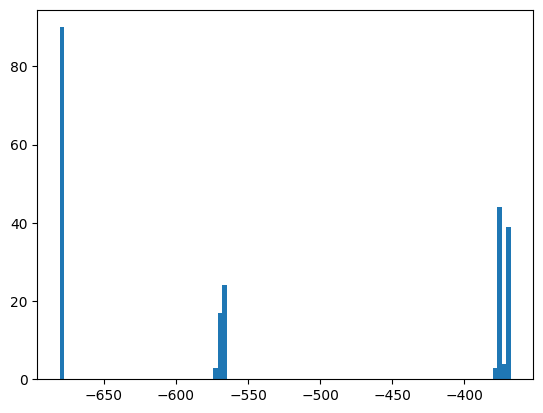

In [32]:
import matplotlib.pyplot as plt
plt.hist(ll_values, bins=100)
plt.show()